# Export to Regular Grid
* Contributor: Martin Diehl (https://martin-diehl.net) and Philip Eisenlohr (eisenlohr@egr.msu.edu)
* DAMASK version: 3.1.0
* Prerequisites (data): DADF5 results file with orientation ('O') and deformation gradient ('F')

## Use case and geometric considerations

Most EBSD visualization and analysis tools assume that the microstructure is represented on a regular Cartesian grid.
This example illustrates how data from a deformed grid-based simulation can be mapped onto such a representation for subsequent visualization.

To achieve this, the distorted periodic geometry is resampled onto a regular grid.
The complexity of this regridding operation depends on the applied deformation.

For simple deformations, such as purely extensional loading, regridding is typically straightforward.
In contrast, shear deformations may require the inclusion of periodic replicas of the simulation domain to recover a regularly periodic volume before resampling.
Consequently, geometries subjected to arbitrary shear are generally unsuitable for direct regridding and export to EBSD-style grid formats.


In [1]:
%matplotlib inline

In [2]:
import damask
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# adjust to your situation, file needs to exist
result_file = 'add_field_data/20grains16x16x16_tensionX_material.hdf5'

In [4]:
result = damask.Result(result_file).view(increments=-1)

In [5]:
F_linear = result.place('F').data
O_linear = result.place('O').data

The deformed geometry is resampled onto a triply refinded regular grid (`cells_resampled`).
The resulting map `idx` translates from the deformed grid points to the regridded ones.

In [6]:
cells_resampled = tuple(result.cells*3)

idx, size_resampled = damask.grid_filters.regrid(result.size,
                                                 damask.grid_filters.unravel(F_linear,result.cells),
                                                 cells_resampled,
                                                 return_size=True)
coords = damask.grid_filters.coordinates0_point(cells_resampled, size_resampled)

Now, orientation data (as Euler angles) can be translated onto the regridded structure.

In [7]:
eu = damask.Rotation.from_quaternion(O_linear)[idx].as_Euler_angles(degrees=True)

For visualization and exporting purposes, we select a two-dimensional slice throught the data, here normal to the $y$ direction as an example.

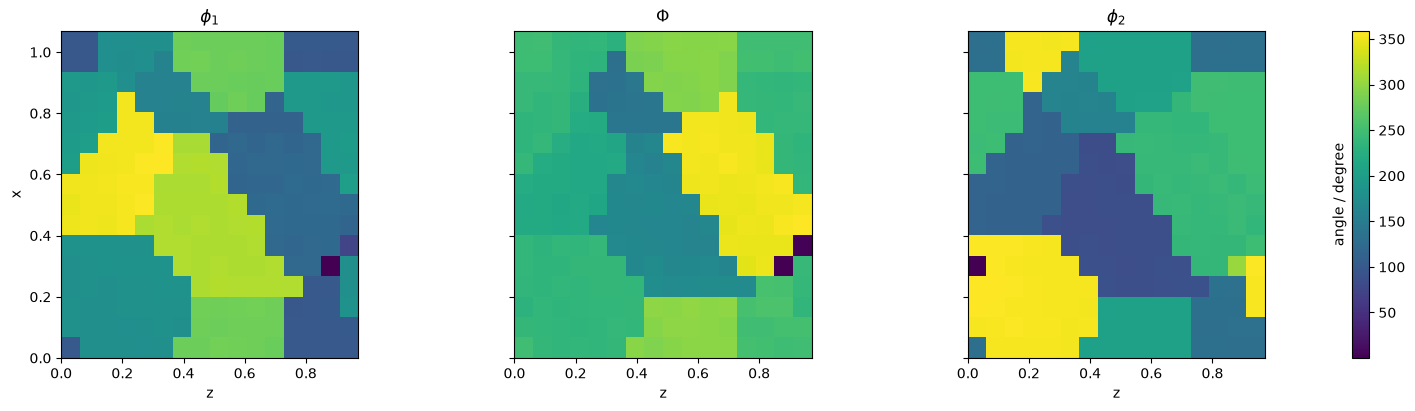

In [8]:
dim = 1                 # x:0, y:1, z:2
sl = 23                 # slice index along `dim`

coords_slice = np.take(coords,sl,axis=dim)
eu_slice = np.take(eu,sl,axis=dim)

X = np.take(coords_slice,[1,2,0][dim],axis=-1)
Y = np.take(coords_slice,[2,0,1][dim],axis=-1)
fields = list(np.moveaxis(eu_slice,-1,0))
titles = [r'$\phi_1$', r'$\Phi$', r'$\phi_2$']

fig, axes = plt.subplots(
    1, len(titles),
    figsize=(15, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, Z, title in zip(axes, fields, titles):

    pcm = ax.pcolormesh(
        X, Y, Z,
        shading='auto',
        cmap='viridis',
    )

    ax.set_title(title)
    ax.set_xlabel(['y','z','x'][dim])
    ax.set_aspect('equal')

axes[0].set_ylabel(['z','x','y'][dim])

# One shared colorbar
cbar = fig.colorbar(
    pcm,
    ax=axes,
    label='angle / degree',
    shrink=1.0,
)
cbar.ax.yaxis.set_label_position('left')
plt.show()

In [9]:
damask.Table() \
    .set('coords',coords_slice.reshape(-1,3)) \
    .set('euler_angles',eu_slice.reshape(-1,3)) \
    .save(f'slice_{['X','Y','Z'][dim]}{sl}_regridded.txt')